# 2주차. 데이터 전처리
### 주제: DACON 갑상선암 진단 분류 데이터

1주차 EDA 결과를 바탕으로 결측치 처리, 이상치 처리, 인코딩, Scaling, Feature Engineering을 수행한다.

**1주차 EDA 주요 결과 요약**
- 결측치: 전 컬럼 0건
- IQR 기준 이상치: 전 수치형 변수 0건
- 타겟(Cancer) 불균형: 양성(0) 88.0% / 악성(1) 12.0%
- 범주형 변수 중 Family_Background, Radiation_History, Iodine_Deficiency, Race, Country가 악성 비율과 뚜렷한 연관을 보임

## 0. 라이브러리 불러오기 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # 한글 폰트 (seaborn 스타일 적용 이후 재설정)
plt.rcParams['axes.unicode_minus'] = False

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

num_cols = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
binary_cols = ['Gender', 'Family_Background', 'Radiation_History', 'Iodine_Deficiency',
               'Smoke', 'Weight_Risk', 'Diabetes']
multi_cat_cols = ['Country', 'Race']

print('train:', train.shape, ' test:', test.shape)
train.head()

train: (87159, 16)  test: (46204, 15)


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


## 1. 결측치 처리

**전처리 방법 설명**
결측치 처리는 데이터에 값이 비어 있는 셀을 채우거나(대체, imputation) 제거하는 작업이다. 일반적으로
① 결측 비율이 매우 낮으면 해당 행을 제거, ② 결측 비율이 높거나 행 제거가 부담스러우면 평균/중앙값/최빈값 등으로 대체,
③ 결측 자체가 의미를 가지는 경우(예: 검사를 받지 않음) '결측' 카테고리를 별도로 만드는 방법 등이 사용된다.

**적용 이유:** 1주차 EDA에서 train/test 전 컬럼에 결측치가 0건임을 확인하였다.

**적용 방법:** 아래 코드로 결측치 존재 여부를 재확인한다.

**적용 결과:** 결측치가 없으므로 별도의 대체/제거 작업을 수행하지 않는다.

In [2]:
print('train 결측치 합계:', train.isnull().sum().sum())
print('test 결측치 합계:', test.isnull().sum().sum())

train 결측치 합계: 0
test 결측치 합계: 0


## 2. 이상치 처리

**전처리 방법 설명**
이상치(Outlier)는 다른 관측치들과 크게 동떨어진 값으로, 모델 학습을 왜곡시킬 수 있어 처리가 필요하다. 대표적인 탐지
방법으로는 ① IQR(사분위범위) 기준(Q1-1.5×IQR ~ Q3+1.5×IQR 범위를 벗어나는 값), ② Z-score 기준(평균에서
표준편차의 특정 배수(보통 3배) 이상 벗어난 값)이 있다. 이상치가 발견되면 제거하거나, 상한/하한값으로 대체(Capping)하는
방법을 주로 사용한다.

**적용 이유:** 1주차에는 IQR 기준으로만 확인하였으므로, 2주차에서는 Z-score 기준을 추가로 적용하여 교차 검증한다.

**적용 방법:** 수치형 변수 5종에 대해 Z-score(|z| > 3)를 계산하여 이상치 개수를 확인한다.

**적용 결과:** 아래에서 확인한다.

In [3]:
from scipy import stats

for col in num_cols:
    z = np.abs(stats.zscore(train[col]))
    n_out = (z > 3).sum()
    print(f'{col:15s} | Z-score 이상치 개수: {n_out:5d} | 비율: {n_out/len(train)*100:.3f}%')

Age             | Z-score 이상치 개수:     0 | 비율: 0.000%
Nodule_Size     | Z-score 이상치 개수:     0 | 비율: 0.000%
TSH_Result      | Z-score 이상치 개수:     0 | 비율: 0.000%
T4_Result       | Z-score 이상치 개수:     0 | 비율: 0.000%
T3_Result       | Z-score 이상치 개수:     0 | 비율: 0.000%


Z-score 기준으로도 이상치가 거의 발견되지 않는다(수치형 변수가 특정 범위 내 균등분포를 이루기 때문). 따라서
본 데이터셋에서는 별도의 이상치 제거/대체 작업을 수행하지 않는다.

## 3. 인코딩(Encoding)

**전처리 방법 설명**
머신러닝 모델은 문자열(범주형) 데이터를 직접 학습할 수 없으므로 숫자로 변환하는 인코딩이 필요하다.
- **Label/Binary Encoding:** 범주가 2개인 변수는 0/1로 단순 매핑해도 순서·크기 정보의 왜곡이 없다.
- **One-Hot Encoding:** 범주가 3개 이상이고 순서가 없는 명목형 변수는 범주 수만큼의 이진 컬럼으로 변환하여
  범주 간 크기 관계가 생기지 않도록 한다.

**적용 이유:** 이진 범주형 변수(Gender, Family_Background, Radiation_History, Iodine_Deficiency, Smoke,
Weight_Risk, Diabetes) 7개는 범주가 2개뿐이므로 Binary Encoding을, 다범주형 변수(Country 10개, Race 5개)는
순서가 없는 명목형이므로 One-Hot Encoding을 적용한다.

**적용 방법:** 아래에서 각각 적용한다.

In [4]:
# 3-1. 이진 범주형 변수 Binary Encoding
train_enc = train.copy()
test_enc = test.copy()

binary_maps = {}
for col in binary_cols:
    categories = sorted(train[col].unique())
    mapping = {cat: i for i, cat in enumerate(categories)}
    binary_maps[col] = mapping
    train_enc[col] = train_enc[col].map(mapping)
    test_enc[col] = test_enc[col].map(mapping)

for col, mapping in binary_maps.items():
    print(f'{col:20s} -> {mapping}')

Gender               -> {'F': 0, 'M': 1}
Family_Background    -> {'Negative': 0, 'Positive': 1}
Radiation_History    -> {'Exposed': 0, 'Unexposed': 1}
Iodine_Deficiency    -> {'Deficient': 0, 'Sufficient': 1}
Smoke                -> {'Non-Smoker': 0, 'Smoker': 1}
Weight_Risk          -> {'Not Obese': 0, 'Obese': 1}
Diabetes             -> {'No': 0, 'Yes': 1}


In [5]:
# 3-2. 다범주형 변수 One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(train[multi_cat_cols])

train_ohe = pd.DataFrame(
    ohe.transform(train[multi_cat_cols]),
    columns=ohe.get_feature_names_out(multi_cat_cols),
    index=train.index
)
test_ohe = pd.DataFrame(
    ohe.transform(test[multi_cat_cols]),
    columns=ohe.get_feature_names_out(multi_cat_cols),
    index=test.index
)

train_enc = pd.concat([train_enc.drop(columns=multi_cat_cols), train_ohe], axis=1)
test_enc = pd.concat([test_enc.drop(columns=multi_cat_cols), test_ohe], axis=1)

print('One-Hot 인코딩 후 컬럼 수:', train_enc.shape[1])
train_enc.head()

One-Hot 인코딩 후 컬럼 수: 29


,ID,Age,Gender,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,...,Country_JPN,Country_KOR,Country_NGA,Country_RUS,Country_USA,Race_AFR,Race_ASN,Race_CAU,Race_HSP,Race_MDE
0,TRAIN_00000,80,1,1,0,1,0,0,0,0.650355,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,TRAIN_00001,37,1,1,1,1,1,1,0,2.950430,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,TRAIN_00002,71,1,1,1,1,0,0,1,2.200023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,TRAIN_00003,40,0,0,1,1,0,1,0,3.370796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,TRAIN_00004,53,0,0,1,1,0,0,0,4.230048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**적용 결과:** 이진 범주형 변수 7개는 0/1 값으로 변환되었고, Country(10개)와 Race(5개)는 각각 10개, 5개의
One-Hot 컬럼으로 확장되어 총 컬럼 수가 늘어났다. 인코딩 후에도 train과 test의 컬럼 구성이 동일함을 확인하였다.

In [6]:
# train/test 컬럼 정합성 확인
train_cols = set(train_enc.columns) - {'Cancer'}
test_cols = set(test_enc.columns)
print('train/test 컬럼 일치 여부:', train_cols == test_cols)

train/test 컬럼 일치 여부: True


## 4. Scaling

**전처리 방법 설명**
Scaling은 변수마다 다른 값의 범위(단위)를 동일한 척도로 맞추는 작업이다. 거리 기반 모델(KNN, SVM)이나
경사하강법 기반 모델(로지스틱 회귀, 신경망)은 변수 간 스케일 차이가 크면 특정 변수가 과도한 영향을 미칠 수 있어
Scaling이 필요하다. 대표적으로 평균 0, 표준편차 1로 변환하는 **StandardScaler**와 최소값 0, 최대값 1로
변환하는 **MinMaxScaler**가 있다.

**적용 이유:** 1주차·2주차 EDA에서 확인했듯 수치형 변수 5종은 이상치가 거의 없고 특정 범위 내 균등분포에
가까우므로, 이상치에 민감하지 않은 StandardScaler를 적용한다. (이상치가 많았다면 RobustScaler를 고려했을 것이다.)

**적용 방법:** train 데이터의 수치형 변수 5종에 대해 StandardScaler를 fit한 뒤 train/test에 동일하게 적용한다.

In [7]:
scaler = StandardScaler()
train_enc[num_cols] = scaler.fit_transform(train_enc[num_cols])
test_enc[num_cols] = scaler.transform(test_enc[num_cols])

train_enc[num_cols].describe().round(3)

,Age,Nodule_Size,TSH_Result,T4_Result,T3_Result
count,87159.000,87159.000,87159.000,87159.000,87159.000
mean,0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.703,-1.739,-1.732,-1.731,-1.736
25%,-0.872,-0.858,-0.865,-0.866,-0.865
50%,0.006,0.009,0.001,-0.006,-0.001
75%,0.885,0.869,0.868,0.867,0.869
max,1.716,1.728,1.728,1.732,1.724


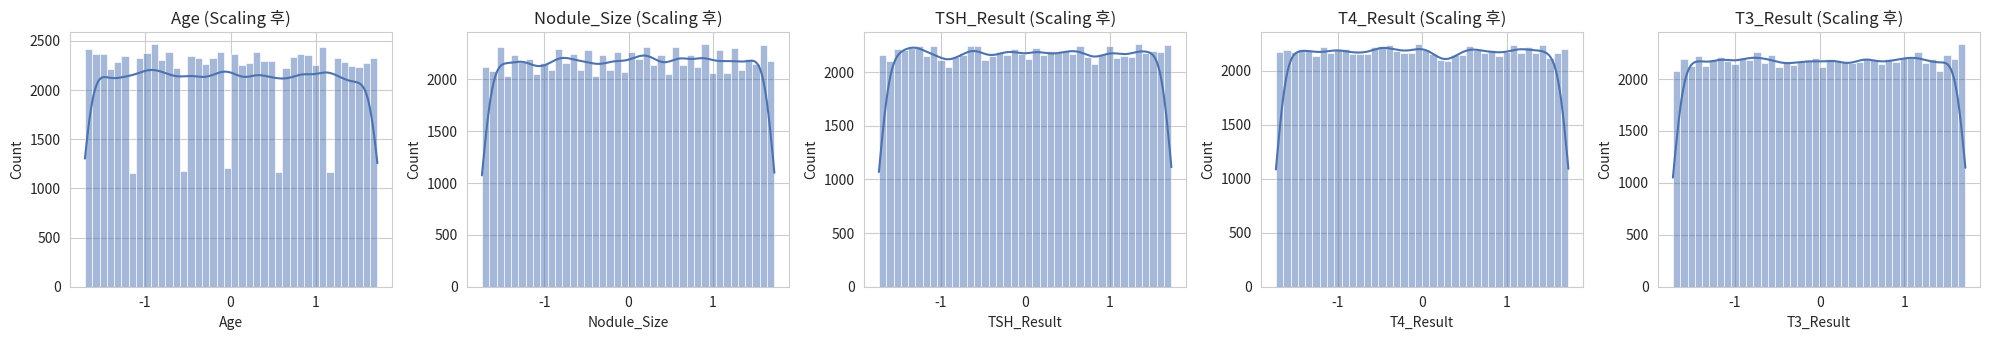

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for i, col in enumerate(num_cols):
    sns.histplot(train_enc[col], bins=40, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col} (Scaling 후)')
plt.tight_layout()
plt.savefig('imgs2/01_scaled_hist.png', dpi=120)
plt.show()

**적용 결과:** Scaling 후 모든 수치형 변수의 평균이 0, 표준편차가 1에 가까워졌으며, 분포의 형태(균등분포)
자체는 유지된 채 값의 범위만 조정되었다.

## 5. Feature Engineering (선택)

**적용 이유:** 1주차 EDA에서 Family_Background(가족력), Radiation_History(방사선 노출력), Iodine_Deficiency(요오드
결핍)는 각각 악성 비율과 뚜렷한 연관을 보였다(정상 대비 각각 +7.7%p, +7.0%p, +6.1%p). 이 세 가지 위험 요인을
개별 변수로 두는 것보다, 한 사람이 위험 요인을 몇 개나 가지고 있는지를 나타내는 **위험도 점수(Risk_Score)**
파생 변수를 만들면 위험 요인의 '누적 효과'를 모델이 더 쉽게 학습할 수 있을 것이라는 아이디어로 생성하였다.

**적용 방법:** 인코딩 이전의 원본 범주(Positive/Exposed/Deficient = 1)를 기준으로 세 변수를 합산하여 0~3
사이의 정수 점수를 만든다.

In [9]:
risk_family = (train['Family_Background'] == 'Positive').astype(int)
risk_radiation = (train['Radiation_History'] == 'Exposed').astype(int)
risk_iodine = (train['Iodine_Deficiency'] == 'Deficient').astype(int)

train_enc['Risk_Score'] = risk_family + risk_radiation + risk_iodine

# test에도 동일하게 적용
risk_family_t = (test['Family_Background'] == 'Positive').astype(int)
risk_radiation_t = (test['Radiation_History'] == 'Exposed').astype(int)
risk_iodine_t = (test['Iodine_Deficiency'] == 'Deficient').astype(int)
test_enc['Risk_Score'] = risk_family_t + risk_radiation_t + risk_iodine_t

train_enc['Risk_Score'].value_counts().sort_index()

Risk_Score
0    40821
1    35592
2     9896
3      850
Name: count, dtype: int64

Risk_Score
0    0.0727
1    0.1462
2    0.2070
3    0.2859
Name: Cancer, dtype: float64


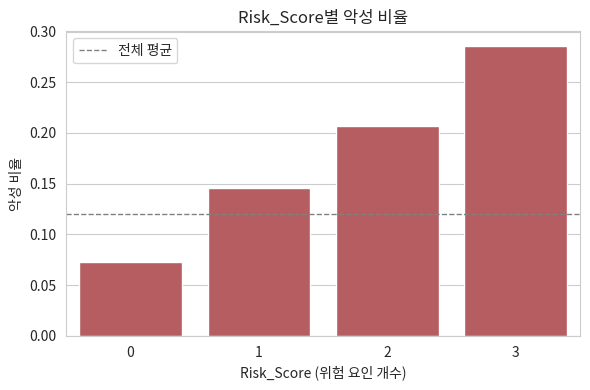

In [10]:
risk_cancer_rate = train.assign(Risk_Score=train_enc['Risk_Score']).groupby('Risk_Score')['Cancer'].mean()
print(risk_cancer_rate.round(4))

plt.figure(figsize=(6, 4))
sns.barplot(x=risk_cancer_rate.index, y=risk_cancer_rate.values, color='#C44E52')
plt.axhline(train['Cancer'].mean(), color='gray', linestyle='--', linewidth=1, label='전체 평균')
plt.title('Risk_Score별 악성 비율')
plt.xlabel('Risk_Score (위험 요인 개수)')
plt.ylabel('악성 비율')
plt.legend()
plt.tight_layout()
plt.savefig('imgs2/02_risk_score.png', dpi=120)
plt.show()

**적용 결과:** Risk_Score가 0에서 3으로 증가할수록 악성 비율이 단조적으로 증가하는 경향이 뚜렷하게 나타났다.
개별 위험 요인 변수만 볼 때보다 위험 요인이 누적될수록 악성 비율이 커진다는 관계가 더 명확하게 드러나므로,
3주차 모델링에서 유용한 변수가 될 것으로 기대한다.

## 6. 전처리 결과 정리

In [11]:
print('전처리 전 train shape:', train.shape)
print('전처리 후 train shape:', train_enc.shape)
print()
print('전처리 후 컬럼 목록:')
print(list(train_enc.columns))

전처리 전 train shape: (87159, 16)
전처리 후 train shape: (87159, 30)

전처리 후 컬럼 목록:
['ID', 'Age', 'Gender', 'Family_Background', 'Radiation_History', 'Iodine_Deficiency', 'Smoke', 'Weight_Risk', 'Diabetes', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result', 'Cancer', 'Country_BRA', 'Country_CHN', 'Country_DEU', 'Country_GBR', 'Country_IND', 'Country_JPN', 'Country_KOR', 'Country_NGA', 'Country_RUS', 'Country_USA', 'Race_AFR', 'Race_ASN', 'Race_CAU', 'Race_HSP', 'Race_MDE', 'Risk_Score']


In [12]:
# 전처리 완료 데이터 저장 (3주차 모델링에서 재사용)
train_enc.to_csv('train_preprocessed.csv', index=False)
test_enc.to_csv('test_preprocessed.csv', index=False)
print('저장 완료')

저장 완료


## 결론

- 결측치: 없음을 재확인, 처리 불필요
- 이상치: IQR·Z-score 두 기준 모두에서 이상치가 거의 발견되지 않아 별도 처리를 하지 않음
- 인코딩: 이진 범주형 7개는 Binary Encoding, 다범주형 2개(Country, Race)는 One-Hot Encoding 적용
- Scaling: 수치형 변수 5개에 StandardScaler 적용
- Feature Engineering: 가족력·방사선 노출·요오드 결핍을 합산한 Risk_Score 파생 변수를 생성하였으며, 이 변수는
  값이 커질수록 악성 비율이 뚜렷하게 증가하는 것을 확인함

세부 해석 및 다음 주차(모델링) 계획은 보고서(PDF)에 정리하였다.